In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

sns.set_theme()


## 1. Load the Data\n

In [6]:
# Load portfolios
df_iv = pd.read_csv('data/portfolios/inv_vol.csv', index_col=0, parse_dates=True)
df_ew = pd.read_csv('data/portfolios/ew_returns.csv', index_col=0, parse_dates=True)

# Load S&P 500
df_sp500 = pd.read_csv('data/hf_returns/sp500.csv', index_col=0, parse_dates=True)

# Align data by date
df = df_iv.join(df_ew, lsuffix='_iv', rsuffix='_ew', how='inner')
df = df.join(df_sp500['SP500TR'], how='inner')

# Rename columns for clarity
df.columns = ['iv', 'ew', 'sp500']

# Drop NaNs
df = df.dropna()

print(f"Data aligned from {df.index.min().date()} to {df.index.max().date()} with {len(df)} months.")


Data aligned from 2020-01-01 to 2026-04-01 with 76 months.


## 2. Define Metrics (from `portfolio_bootstrap.ipynb`)\n

In [7]:
def calculate_metrics(returns, sp500_returns):
    """
    Calculate comprehensive portfolio metrics from a series of monthly returns.
    """
    # 1. Mean Return (Annualized) %
    mean_return_ann = returns.mean() * 12 * 100
    
    # 2. CAGR %
    cum_return = (1 + returns).prod()
    n_years = len(returns) / 12
    cagr = (cum_return ** (1 / n_years) - 1 if n_years > 0 else np.nan) * 100
    
    # 3. Volatility (Annualized) %
    volatility = returns.std() * np.sqrt(12) * 100
    
    # 4. Sharpe Ratio (Annualized)
    sharpe_ratio_ann = (returns.mean() / returns.std() * np.sqrt(12)) if returns.std() != 0 else np.nan
    
    # 5. Max Drawdown %
    cum_index = (1 + returns).cumprod()
    running_max = cum_index.cummax()
    drawdown = (cum_index - running_max) / running_max
    max_drawdown = drawdown.min() * 100
    
    # 6. Calmar Ratio
    calmar_ratio = cagr / abs(max_drawdown) if max_drawdown != 0 else np.nan
    
    # 7. Correlation with S&P 500
    correlation = returns.corr(sp500_returns)
    
    # 8. Proportion of Positive Months %
    pos_months = (returns > 0).mean() * 100
    
    # 9. Upside / Downside Capture (%)
    up_idx = sp500_returns > 0
    down_idx = sp500_returns < 0
    
    port_up_ret = (1 + returns[up_idx]).prod() - 1
    sp500_up_ret = (1 + sp500_returns[up_idx]).prod() - 1
    up_capture = (port_up_ret / sp500_up_ret * 100) if sp500_up_ret != 0 else np.nan
    
    port_down_ret = (1 + returns[down_idx]).prod() - 1
    sp500_down_ret = (1 + sp500_returns[down_idx]).prod() - 1
    down_capture = (port_down_ret / sp500_down_ret * 100) if sp500_down_ret != 0 else np.nan
    
    # 10. Correlation when S&P500 is below its 1st quartile
    q1_sp500 = sp500_returns.quantile(0.25)
    below_q1_idx = sp500_returns < q1_sp500
    corr_below_q1 = returns[below_q1_idx].corr(sp500_returns[below_q1_idx])
    
    # 11. Regression Metrics (Alpha, Beta, R2, t-stats)
    y = returns.values
    x = sp500_returns.values
    n = len(x)
    
    cov_matrix = np.cov(x, y)
    beta = cov_matrix[0, 1] / cov_matrix[0, 0] if cov_matrix[0, 0] != 0 else np.nan
    alpha = np.mean(y) - beta * np.mean(x)
    
    y_pred = alpha + beta * x
    residuals = y - y_pred
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    
    r2 = (1 - (ss_res / ss_tot)) * 100 if ss_tot != 0 else np.nan
    
    s_err = np.sqrt(ss_res / (n - 2)) if n > 2 else np.nan
    ss_xx = np.sum((x - np.mean(x))**2)
    
    beta_se = s_err / np.sqrt(ss_xx) if ss_xx != 0 else np.nan
    alpha_se = s_err * np.sqrt(1/n + (np.mean(x)**2) / ss_xx) if ss_xx != 0 else np.nan
    
    beta_tstat = beta / beta_se if beta_se != 0 and not np.isnan(beta_se) else np.nan
    alpha_tstat = alpha / alpha_se if alpha_se != 0 and not np.isnan(alpha_se) else np.nan
    
    # Annualized Alpha (converted to %)
    alpha_ann = ((1 + alpha)**12 - 1) * 100
    
    return {
        'Mean Return (Ann) %': mean_return_ann,
        'CAGR %': cagr,
        'Volatility (Ann) %': volatility,
        'Sharpe Ratio (Ann)': sharpe_ratio_ann,
        'Max Drawdown %': max_drawdown,
        'Calmar Ratio': calmar_ratio,
        'Correlation with SP500': correlation,
        'Positive Months %': pos_months,
        'Upside Capture %': up_capture,
        'Downside Capture %': down_capture,
        'Correlation (SP500 < Q1)': corr_below_q1,
        'Beta': beta,
        'Beta t-stat': beta_tstat,
        'Alpha (Ann) %': alpha_ann,
        'Alpha t-stat': alpha_tstat,
        'R-squared %': r2
    }


## 3. Block Bootstrap Analysis (b=3)\n

In [8]:
def run_block_bootstrap(df, b=3, n_boot=1000):
    n = len(df)
    # Number of possible starting points for a block of size b
    indices = np.arange(n - b + 1)
    
    res_iv = []
    res_ew = []
    
    np.random.seed(42) # For reproducibility
    
    for _ in tqdm(range(n_boot), desc=f"Block Bootstrap (b={b})"):
        sampled_indices = []
        while len(sampled_indices) < n:
            start_idx = np.random.choice(indices)
            sampled_indices.extend(range(start_idx, start_idx + b))
            
        sampled_indices = sampled_indices[:n]
        
        boot_iv = pd.Series(df['iv'].iloc[sampled_indices].values)
        boot_ew = pd.Series(df['ew'].iloc[sampled_indices].values)
        boot_sp500 = pd.Series(df['sp500'].iloc[sampled_indices].values)
        
        res_iv.append(calculate_metrics(boot_iv, boot_sp500))
        res_ew.append(calculate_metrics(boot_ew, boot_sp500))
        
    return pd.DataFrame(res_iv), pd.DataFrame(res_ew)

df_res_iv, df_res_ew = run_block_bootstrap(df, b=3, n_boot=1000)

# Calculate actual metrics for original portfolios\n
actual_iv = calculate_metrics(df['iv'], df['sp500'])
actual_ew = calculate_metrics(df['ew'], df['sp500'])


Block Bootstrap (b=3): 100%|██████████| 1000/1000 [00:01<00:00, 679.16it/s]


## 4. Plot Distributions and CDFs\n

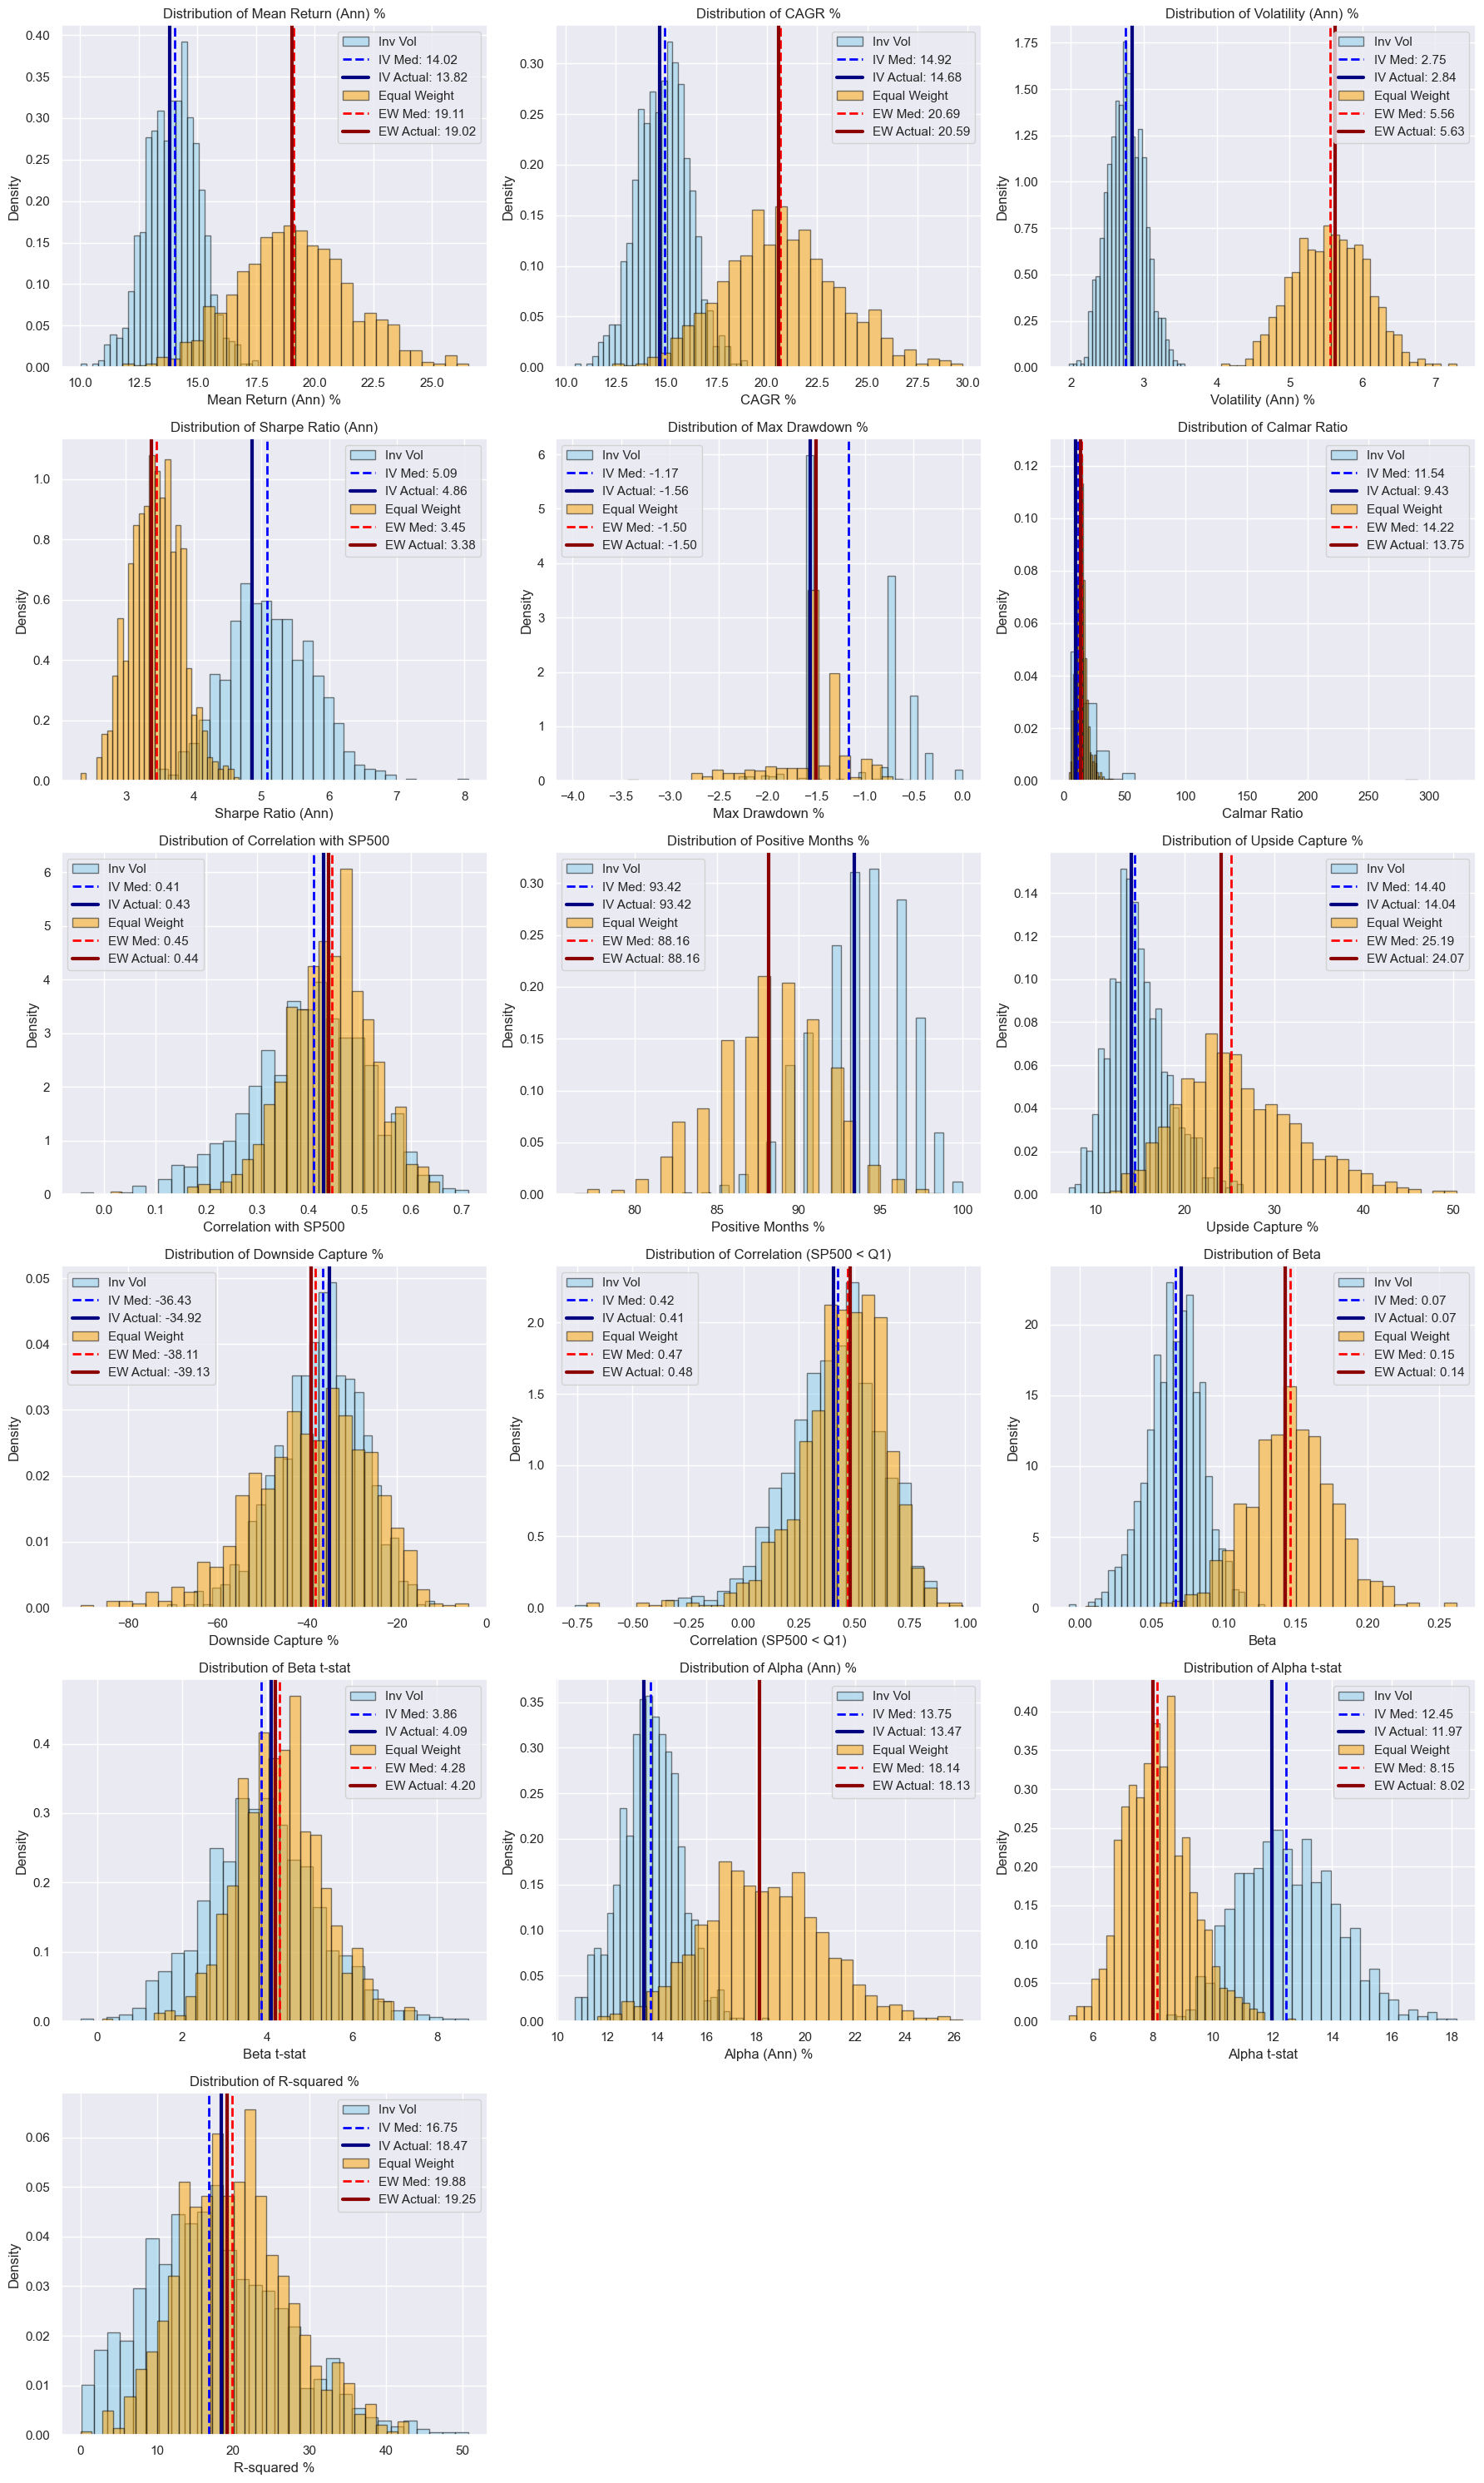

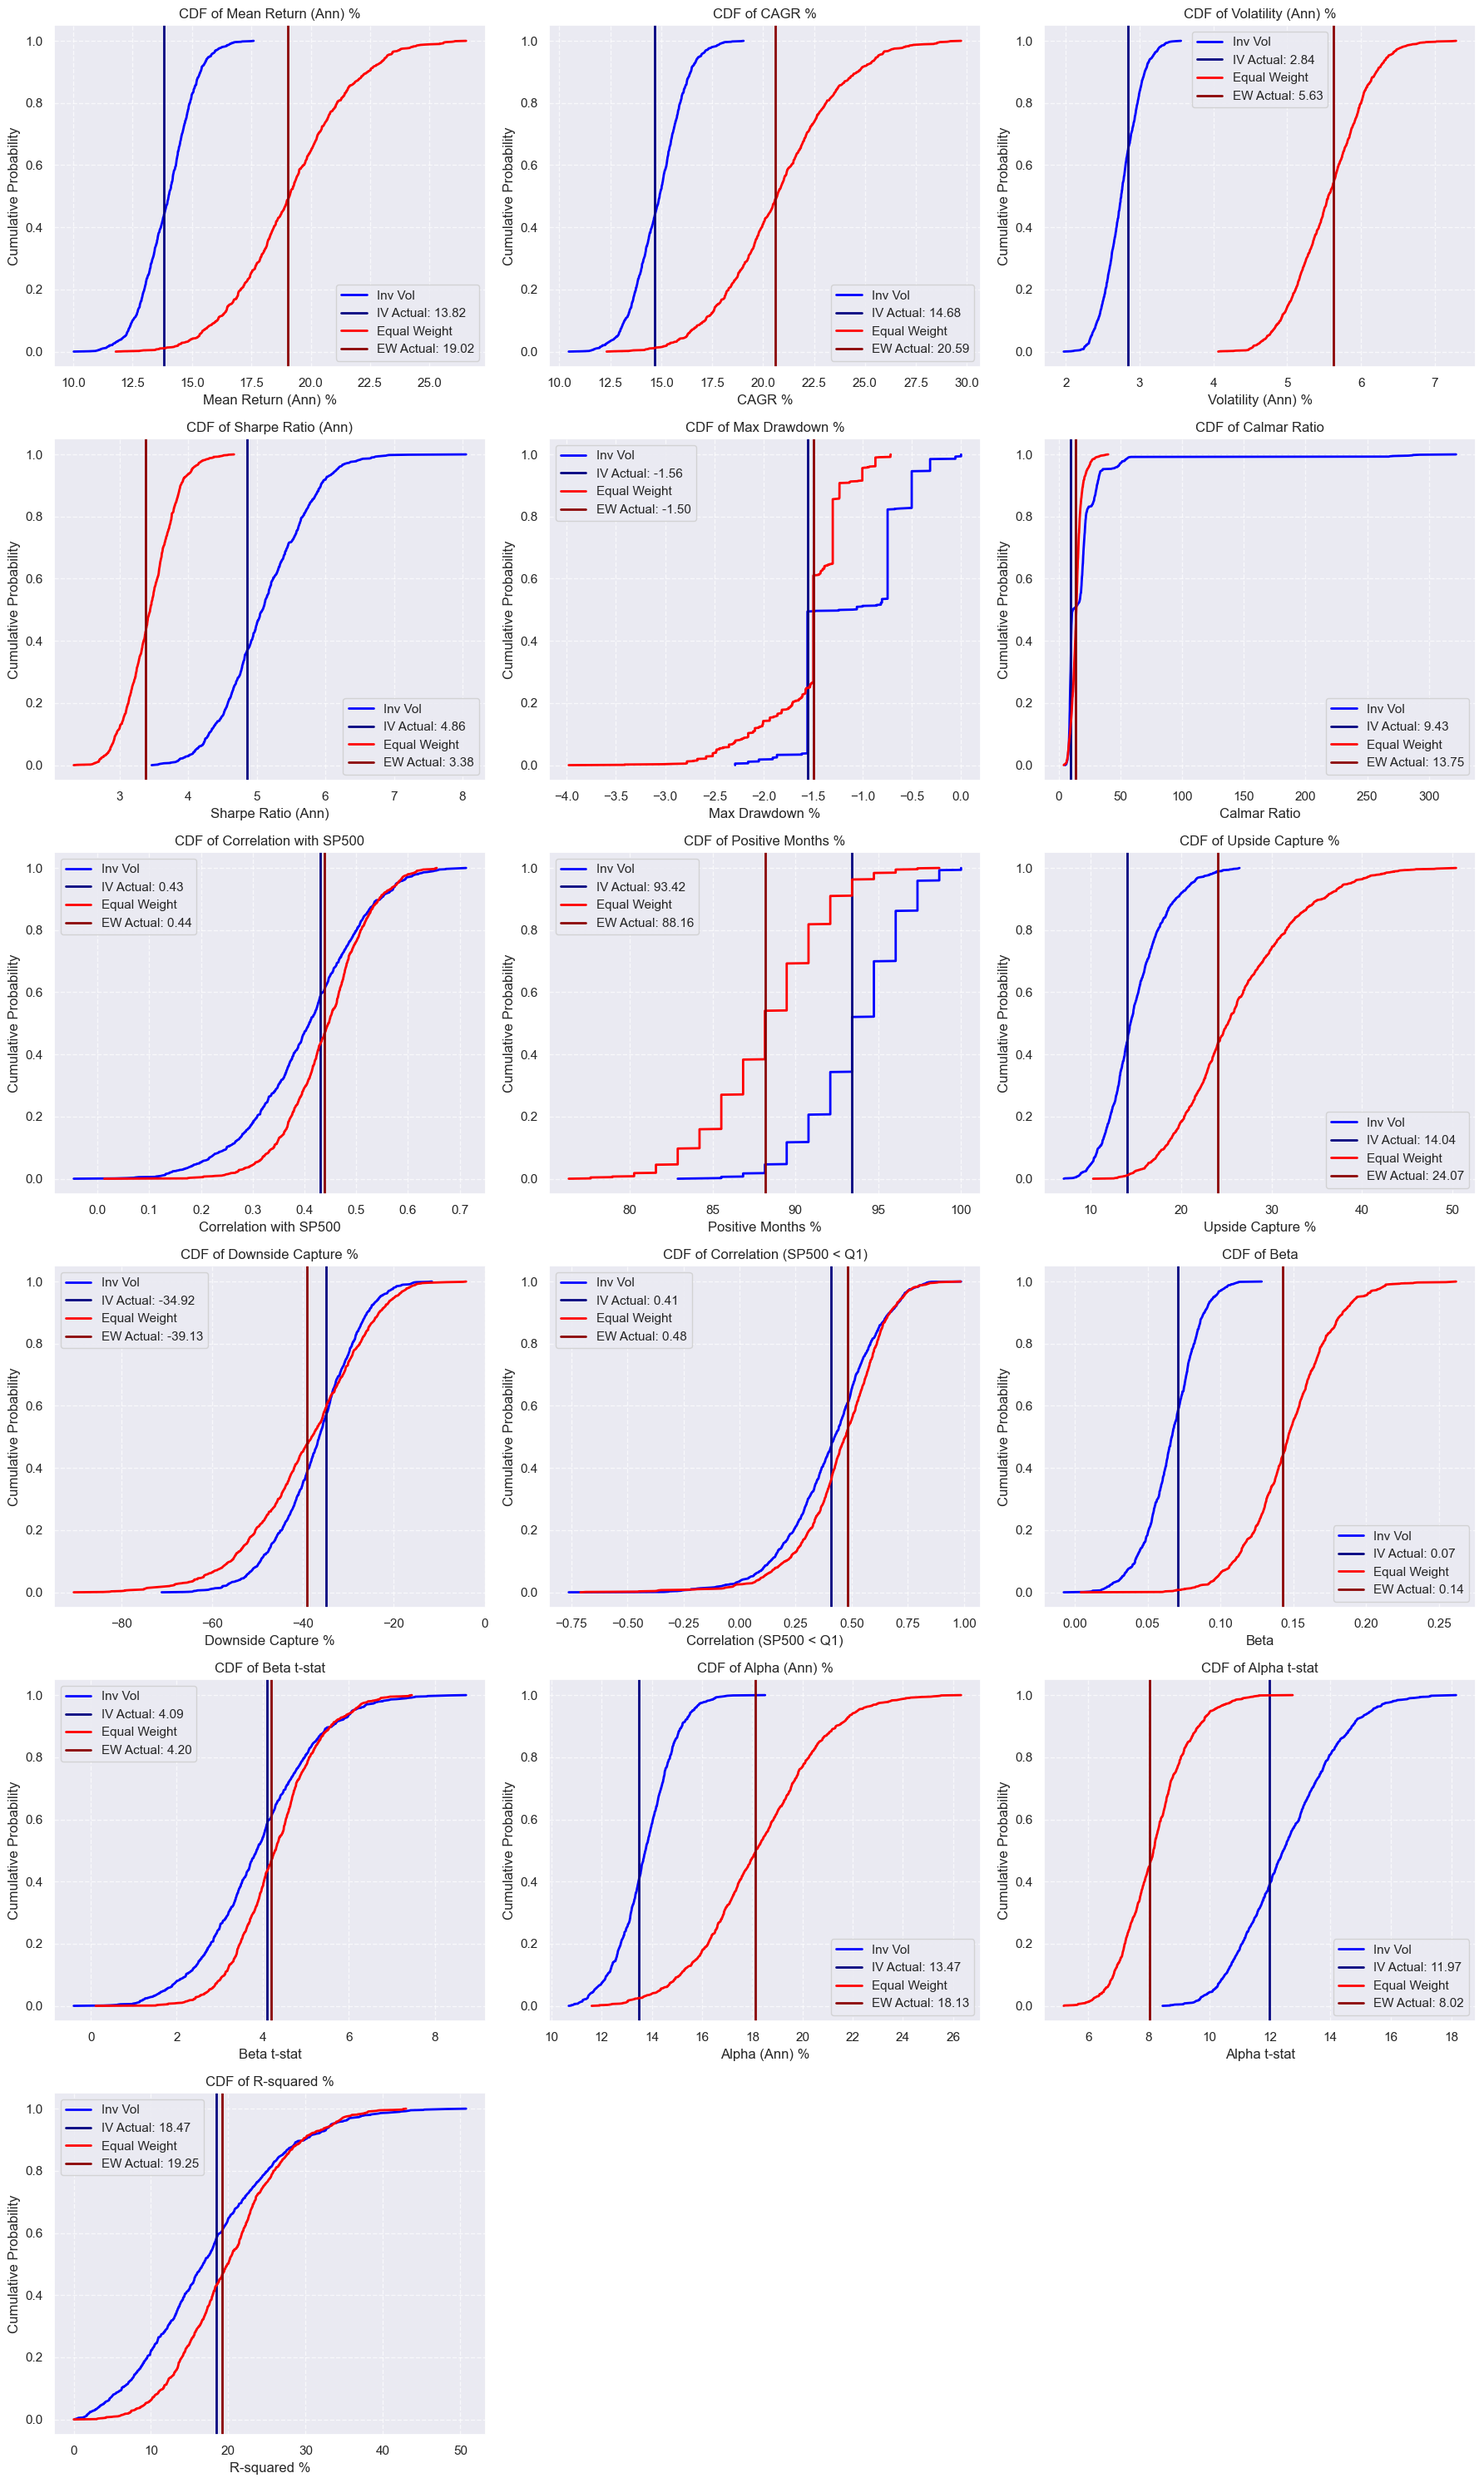

In [9]:
metrics_to_plot = [
    'Mean Return (Ann) %', 
    'CAGR %', 
    'Volatility (Ann) %', 
    'Sharpe Ratio (Ann)', 
    'Max Drawdown %', 
    'Calmar Ratio', 
    'Correlation with SP500',
    'Positive Months %',
    'Upside Capture %',
    'Downside Capture %',
    'Correlation (SP500 < Q1)',
    'Beta',
    'Beta t-stat',
    'Alpha (Ann) %',
    'Alpha t-stat',
    'R-squared %'
]

def plot_distributions_and_cdfs(res_iv, res_ew, actual_iv, actual_ew):
    n_metrics = len(metrics_to_plot)
    
    # Plot Histograms
    nrows = int(np.ceil(n_metrics / 3))
    fig, axes = plt.subplots(nrows, 3, figsize=(18, 5 * nrows))
    axes = axes.flatten()
    
    for i, metric in enumerate(metrics_to_plot):
        ax = axes[i]
        
        d_iv = res_iv[metric].dropna()
        ax.hist(d_iv, bins=30, color='skyblue', edgecolor='black', alpha=0.5, label='Inv Vol', density=True)
        med_iv = d_iv.median()
        ax.axvline(med_iv, color='blue', linestyle='dashed', linewidth=2, label=f'IV Med: {med_iv:.2f}')
        ax.axvline(actual_iv[metric], color='navy', linestyle='solid', linewidth=3, label=f'IV Actual: {actual_iv[metric]:.2f}')
        
        d_ew = res_ew[metric].dropna()
        ax.hist(d_ew, bins=30, color='orange', edgecolor='black', alpha=0.5, label='Equal Weight', density=True)
        med_ew = d_ew.median()
        ax.axvline(med_ew, color='red', linestyle='dashed', linewidth=2, label=f'EW Med: {med_ew:.2f}')
        ax.axvline(actual_ew[metric], color='darkred', linestyle='solid', linewidth=3, label=f'EW Actual: {actual_ew[metric]:.2f}')
        
        ax.set_title(f'Distribution of {metric}')
        ax.set_xlabel(metric)
        ax.set_ylabel('Density')
        ax.legend()
        
    for i in range(n_metrics, len(axes)):
        fig.delaxes(axes[i])
        
    plt.tight_layout()
    plt.show()

    # Plot CDFs
    fig, axes = plt.subplots(nrows, 3, figsize=(18, 5 * nrows))
    axes = axes.flatten()
    
    for i, metric in enumerate(metrics_to_plot):
        ax = axes[i]
        
        d_iv = np.sort(res_iv[metric].dropna())
        p_iv = 1. * np.arange(len(d_iv)) / (len(d_iv) - 1)
        ax.plot(d_iv, p_iv, color='blue', linewidth=2, label='Inv Vol')
        ax.axvline(actual_iv[metric], color='navy', linestyle='solid', linewidth=2, label=f'IV Actual: {actual_iv[metric]:.2f}')
        
        d_ew = np.sort(res_ew[metric].dropna())
        p_ew = 1. * np.arange(len(d_ew)) / (len(d_ew) - 1)
        ax.plot(d_ew, p_ew, color='red', linewidth=2, label='Equal Weight')
        ax.axvline(actual_ew[metric], color='darkred', linestyle='solid', linewidth=2, label=f'EW Actual: {actual_ew[metric]:.2f}')
        
        ax.set_title(f'CDF of {metric}')
        ax.set_xlabel(metric)
        ax.set_ylabel('Cumulative Probability')
        ax.legend()
        ax.grid(True, linestyle='--', alpha=0.7)
        
    for i in range(n_metrics, len(axes)):
        fig.delaxes(axes[i])
        
    plt.tight_layout()
    plt.show()

plot_distributions_and_cdfs(df_res_iv, df_res_ew, actual_iv, actual_ew)


In [ ]:
def plot_top_25_sharpe_vol_distribution(res_iv, res_ew, title_prefix=""):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # IV
    if not res_iv.empty:
        q75_iv = res_iv['Sharpe Ratio (Ann)'].quantile(0.75)
        top_25_iv = res_iv[res_iv['Sharpe Ratio (Ann)'] >= q75_iv]
        axes[0].hist(top_25_iv['Volatility (Ann) %'].dropna(), bins=30, color='skyblue', edgecolor='black')
        axes[0].axvline(top_25_iv['Volatility (Ann) %'].median(), color='blue', linestyle='dashed', linewidth=2)
        axes[0].set_title(f'IV Top 25% Sharpe - Volatility\nMedian: {top_25_iv["Volatility (Ann) %"].median():.2f}%')
        axes[0].set_xlabel('Volatility (Ann) %')
        axes[0].set_ylabel('Frequency')
        
    # EW
    if not res_ew.empty:
        q75_ew = res_ew['Sharpe Ratio (Ann)'].quantile(0.75)
        top_25_ew = res_ew[res_ew['Sharpe Ratio (Ann)'] >= q75_ew]
        axes[1].hist(top_25_ew['Volatility (Ann) %'].dropna(), bins=30, color='orange', edgecolor='black')
        axes[1].axvline(top_25_ew['Volatility (Ann) %'].median(), color='red', linestyle='dashed', linewidth=2)
        axes[1].set_title(f'EW Top 25% Sharpe - Volatility\nMedian: {top_25_ew["Volatility (Ann) %"].median():.2f}%')
        axes[1].set_xlabel('Volatility (Ann) %')
        axes[1].set_ylabel('Frequency')
        
    fig.suptitle(f'{title_prefix} Volatility Distribution for Top 25% Sharpe Portfolios', fontsize=14)
    plt.tight_layout()
    plt.show()

print("Top 25% Sharpe Volatility Distribution")
plot_top_25_sharpe_vol_distribution(df_res_iv, df_res_ew, "[Block Bootstrap b=3]")
